## The Future Is Not a Feature: A Look-Ahead Bias-Free Evaluation Framework for Startup Success Prediction through Machine Learning

In [ ]:
%load_ext autoreload
%autoreload 2

import os
from dotenv import load_dotenv 
import yaml

import pandas as pd
import polars as pl
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.impute import KNNImputer

from src.preprocessing import preprocessDataset,getCompleteDatasetWithTimeWindow, getCompleteDatasetWithoutTimeWindow
from src.utils import plot_correlation_heatmap, to_tensors, get_probs, plot_shap_comparison, compute_wilcoxon_table, set_seed,compare_metrics, resolve_tabpfn_token, compute_permutation_shap, get_split


from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
import lightgbm as lgb
from src.models.MLP import MLP
from tabpfn_client import TabPFNClassifier as TabPFNAPIClassifier, set_access_token


from sklearn.metrics import (accuracy_score, f1_score, precision_score, recall_score,
                             classification_report, roc_curve, auc,
                             precision_recall_curve, average_precision_score, roc_auc_score)
import wandb
import shap
import matplotlib.pyplot as plt 


import scipy.integrate
if not hasattr(np, 'trapz'):
    np.trapz = scipy.integrate.trapezoid

load_dotenv()

with open('config/config.yaml', 'r') as f:
    config = yaml.safe_load(f)


timeWindow=int(config['time_window'])

lastYear=int(config['last_year'])

# TabPFN runs through the Prior Labs API, so the session needs an access token.
# It is read from TABPFN_TOKEN, falling back to the token cached outside the
# repository — never from .env, which is tracked by git.
tabpfn_token = resolve_tabpfn_token()
if tabpfn_token is not None:
    set_access_token(tabpfn_token)
else:
    print("TABPFN_TOKEN not found: the 'tabpfn' model will fail. "
          "Export it in the shell before starting the sweep.")

shap_store = {}
metrics_store = {}

# Dataset creation

Include all the steps of the feature and target engineering starting from the panel dataset. 

The original initial panel cannot be released. In _data/raw/panel_example.csv_  there is an example with few records.

Loading of the initial panel and university ranking

In [ ]:
# initialPanel = pl.read_csv(config['paths']['raw_dataset'], null_values=["NA"])

# university_ranking_path = config['paths']['raw_university_ranking']

## Dataset with time window (no look-ahead bias)
Already available in _data/processed/dataset_window.csv_

In [ ]:
# datasetWithTimeWindow = getCompleteDatasetWithTimeWindow(initialPanel,timeWindow,lastYear)

# dataset_window = preprocessDataset(datasetWithTimeWindow,university_ranking_path)

# dataset_window.write_csv(config["paths"]["dataset_window"])

# print("Dataset with time window saved to:", config['paths']['dataset_window'])

Dataset with time window saved to: data/processed/dataset_window.csv


## Dataset without time window (with look ahead bias)
Already available in _data/processed/dataset_nowindow.csv_

In [ ]:
# # need to re-run the previous cell to get dataset_window before running the following code, to ensure that 
# # the firm in the dataset without time window are the same as those in the dataset with time window

# datasetWithNoTimeWindow = getCompleteDatasetWithoutTimeWindow(initialPanel,dataset_window)

# dataset_nowindow = preprocessDataset(datasetWithNoTimeWindow,university_ranking_path,flag_no_time_window=True)

# # to ensure that the firm in the dataset without time window are the same as those in the dataset with time window, we select only those that are present in the dataset with time window (we must keep the same columns and rows in all the experiments to make them comparable)
# dataset_nowindow = dataset_nowindow.select(dataset_window.columns)

# dataset_nowindow.write_csv(config["paths"]["dataset_nowindow"])

# print("Dataset without time window saved to:", config['paths']['dataset_nowindow'])

Dataset without time window saved to: data/processed/dataset_nowindow.csv


## Dataset selection:
(choose one)

Bias controlled experiment

In [6]:
dataset = pd.read_csv(config["paths"]["dataset_window"])
tag="window"

No window experiment (look-ahead bias)

In [11]:
dataset = pd.read_csv(config["paths"]["dataset_nowindow"])
tag="nowindow"

No Team experiment

In [23]:
dataset = pd.read_csv(config["paths"]["dataset_window"])
dataset = dataset.drop(columns= [
    "Total_People",
    "WorkExp_Idx_Mean",
    "Highest_Degree_Mean",
    "Total_Founders",
    "Percent_Females",
    "Avg_Earliest_Year",
    "HasTop50Institute",
    "Is_Eco",
    "Is_Eng",
    "Is_NS",
    "Is_Hum",
    "Is_SS",
    "Is_Med",
    "Is_Law",
    "Is_IT",
    "WorkExperienceIndex_CEO",
    "Gender_CEO_Female"
])
tag="noteam"

No Competitors experiment

In [36]:
dataset = pd.read_csv(config["paths"]["dataset_window"])
dataset = dataset.drop(columns=['SimilarityScoreMean', 'N_Competitors', 'Same_Country'])
tag="nocompetitors"

Feature correlation

In [ ]:
corr_matrix = plot_correlation_heatmap(dataset)

## Split, Imputation and Scaling

Run for each experiment.

One split per evaluation seed (`seeds` in _config/config.yaml_), each with its own imputer and scaler fitted on its own training set. Splits are cached under _tmp/splits_, so this cell is slow only the first time per experiment.

In [37]:
ids = dataset['CompanyID'] 
X = dataset.drop(['CompanyID', 'Target'],axis=1)
y = dataset['Target']

# One independent split per evaluation seed: 60% train, 20% validation
# (threshold tuning), 20% test (final evaluation). Imputer and scaler are
# refitted on each seed's training set inside get_split — sharing them across
# seeds would leak held-out information into every other split.
#
# The KNN imputation costs minutes per split and the sweep revisits each split
# once per model, so get_split caches to tmp/splits (gitignored). Running this
# cell fills the cache; afterwards each run only loads the split it needs.
for seed in config['seeds']:
    get_split(X, y, seed, test_size=config['test_size'], cache_dir='tmp/splits', tag=tag)
    print(f"seed {seed}: split ready")

_probe = get_split(X, y, config['seeds'][0], test_size=config['test_size'],
                   cache_dir='tmp/splits', tag=tag)
print(f"\nTotal: {len(y)} | Train: {len(_probe['y_train'])} | "
      f"Validation: {len(_probe['y_val'])} | Test: {len(_probe['y_test'])} "
      f"| Seeds: {config['seeds']}")

Total: 30297 | Train: 18178 | Validation: 6059 | Test: 6060


## Sweep creation

In [ ]:

entity=os.getenv("entity")
project=os.getenv("project")

# Initialize a new sweep
sweep_id = wandb.sweep(config["sweep_settings"],entity=entity, project=project)


Definition of the training function to be called by wandb agent.

It will be called multiple times by the wandb agent, each time with a different set of hyperparameters defined in the sweep configuration.

The function trains the specified model, evaluates it on the validation and test sets, logs metrics and plots to Weights & Biases, and computes SHAP values for interpretability.

The _tag_ parameter is used to differentiate between different dataset versions (e.g., with or without time window) when storing SHAP values for later comparison.

In [ ]:
def make_train(tag=None):
    def train():
        with wandb.init():
            wandb_config = wandb.config

            # Each run draws its own seed from the sweep. It drives BOTH the
            # split and the model's randomness, so the five runs of a model are
            # five independent replications, not five reruns of one partition —
            # which is what makes the mean +- std in the result tables able to
            # separate a real gap between models from split-to-split noise.
            seed = wandb_config.seed

            split = get_split(X, y, seed, test_size=config['test_size'],
                              cache_dir='tmp/splits', tag=tag)
            X_train, X_val, X_test = split['X_train'], split['X_val'], split['X_test']
            y_train, y_val, y_test = split['y_train'], split['y_val'], split['y_test']
            X_train_imp = split['X_train_imp']
            X_val_imp = split['X_val_imp']
            X_test_imp = split['X_test_imp']
            X_train_scaled = split['X_train_scaled']
            X_val_scaled = split['X_val_scaled']
            X_test_scaled = split['X_test_scaled']

            # Reproducibility: seed Python, NumPy, PyTorch (CPU+CUDA), cuDNN.
            # Sklearn / LightGBM models also get a random_state explicitly below.
            set_seed(seed)
            
            # --- RANDOM FOREST ---
            if wandb_config.model_type == "rf":
                model = RandomForestClassifier(
                    n_estimators= wandb_config.rf_n_estimators, 
                    max_depth= wandb_config.rf_max_depth,  
                    min_samples_leaf= wandb_config.rf_min_samples_leaf,
                    max_features='log2',
                    class_weight='balanced',  
                    random_state=seed
                )

                model.fit(X_train_imp, y_train)
                preds_train = model.predict(X_train_imp)
                preds_val = model.predict(X_val_imp)
                preds_test = model.predict(X_test_imp)
                probs_train = model.predict_proba(X_train_imp)[:, 1]
                probs_val = model.predict_proba(X_val_imp)[:, 1]
                probs_test = model.predict_proba(X_test_imp)[:, 1]

                labels_train = y_train
                labels_val = y_val
                labels_test = y_test

            # --- LGBM ---
            elif wandb_config.model_type == "lgb":
                # Ratio for scale_pos_weight (80/20 -> 4) 
                ratio = float(y_train.value_counts()[0] / y_train.value_counts()[1]) 
                
                model = lgb.LGBMClassifier(
                    n_estimators= wandb_config.lgb_n_estimators, 
                    learning_rate= wandb_config.learning_rate, 
                    max_depth= wandb_config.lgb_max_depth, 
                    scale_pos_weight=ratio,  
                    min_child_weight= wandb_config.min_child_weight, 
                    subsample= wandb_config.subsample,                
                    colsample_bytree= wandb_config.colsample_bytree, 
                    reg_alpha= wandb_config.reg_alpha, 
                    reg_lambda= wandb_config.reg_lambda,
                    random_state=seed,
                )

                model.fit(X_train_imp, y_train)
                preds_train = model.predict(X_train_imp)
                preds_val = model.predict(X_val_imp)
                preds_test = model.predict(X_test_imp)
                probs_train = model.predict_proba(X_train_imp)[:, 1]
                probs_val = model.predict_proba(X_val_imp)[:, 1]
                probs_test = model.predict_proba(X_test_imp)[:, 1]

                labels_train = y_train
                labels_val = y_val
                labels_test = y_test

            # --- DECISION TREE ---
            elif wandb_config.model_type == "dt":
                model = DecisionTreeClassifier(
                    max_depth=wandb_config.dt_max_depth,
                    min_samples_leaf=wandb_config.dt_min_samples_leaf,
                    min_samples_split=wandb_config.dt_min_samples_split,
                    criterion=wandb_config.dt_criterion,
                    class_weight='balanced',
                    random_state=seed
                )

                model.fit(X_train_imp, y_train)
                preds_train = model.predict(X_train_imp)
                preds_val = model.predict(X_val_imp)
                preds_test = model.predict(X_test_imp)
                probs_train = model.predict_proba(X_train_imp)[:, 1]
                probs_val = model.predict_proba(X_val_imp)[:, 1]
                probs_test = model.predict_proba(X_test_imp)[:, 1]

                labels_train = y_train
                labels_val = y_val
                labels_test = y_test

            # --- LOGISTIC REGRESSION  ---
            elif wandb_config.model_type == "lr":
                model = LogisticRegression(
                    C=wandb_config.lr_C,  
                    penalty=wandb_config.lr_penalty,
                    solver='saga',
                    class_weight='balanced',
                    max_iter=1000,
                    random_state=seed
                )

                model.fit(X_train_scaled, y_train)
                preds_train = model.predict(X_train_scaled)
                preds_val = model.predict(X_val_scaled)
                preds_test = model.predict(X_test_scaled)
                probs_train = model.predict_proba(X_train_scaled)[:, 1]
                probs_val = model.predict_proba(X_val_scaled)[:, 1]
                probs_test = model.predict_proba(X_test_scaled)[:, 1]

                labels_train = y_train
                labels_val = y_val
                labels_test = y_test

            # --- SVM (RBF KERNEL) ---
            elif wandb_config.model_type == "svm":
                model = SVC(
                    C=wandb_config.svm_C,
                    gamma=wandb_config.svm_gamma,
                    kernel='rbf',
                    probability=True,
                    class_weight='balanced',
                    cache_size=1000,
                    random_state=seed
                )

                # Scaled, like LR and the MLP: an RBF kernel compares distances,
                # so unscaled features would let the widest-range column dominate.
                model.fit(X_train_scaled, y_train)
                probs_train = model.predict_proba(X_train_scaled)[:, 1]
                probs_val = model.predict_proba(X_val_scaled)[:, 1]
                probs_test = model.predict_proba(X_test_scaled)[:, 1]

                # Thresholded on the probability rather than taken from
                # model.predict(): for SVC the two disagree, because predict()
                # uses the sign of the decision function while predict_proba()
                # goes through Platt scaling. Every other model here decides at
                # p >= 0.5, and the comparison table is only meaningful if the
                # SVM decides the same way.
                preds_train = (probs_train >= 0.5).astype(int)
                preds_val = (probs_val >= 0.5).astype(int)
                preds_test = (probs_test >= 0.5).astype(int)

                labels_train = y_train
                labels_val = y_val
                labels_test = y_test

            elif wandb_config.model_type == "mlp":
                # ── SWEEP HYPERPARAMETERS ──
                hidden_sizes = [int(x) for x in wandb_config.hidden_sizes.split(",")] 
                mlp_lr = wandb_config.mlp_learning_rate 
                mlp_dropout = wandb_config.dropout_rate 
                mlp_wd = wandb_config.weight_decay
                BATCH_SIZE = wandb_config.batch_size 

                # ── TENSOR CONVERSION ──
                X_train_t, y_train_t = to_tensors(X_train_scaled, y_train)
                X_val_t,   y_val_t   = to_tensors(X_val_scaled,   y_val)
                X_test_t,  y_test_t  = to_tensors(X_test_scaled,  y_test)

                # ── DATALOADER ──
                # Seeded generator so that shuffle order is reproducible across runs.
                train_generator = torch.Generator()
                train_generator.manual_seed(seed)
                train_loader = DataLoader(TensorDataset(X_train_t, y_train_t),
                                        batch_size=BATCH_SIZE, shuffle=True,
                                        generator=train_generator)
                val_loader   = DataLoader(TensorDataset(X_val_t, y_val_t),
                                        batch_size=BATCH_SIZE)
                test_loader  = DataLoader(TensorDataset(X_test_t, y_test_t),
                                        batch_size=BATCH_SIZE)

                # ── MODEL, LOSS, OPTIMIZER ──
                device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

                model = MLP(
                    input_size=X_train_scaled.shape[1],
                    hidden_sizes=hidden_sizes,
                    dropout_rate=mlp_dropout,
                    batch_norm=True
                ).to(device)

                # Class weight: pos_weight = n_neg / n_pos (loss balancing)
                n_pos = y_train.sum()
                n_neg = len(y_train) - n_pos
                pos_weight = torch.tensor([n_neg / n_pos], dtype=torch.float32).to(device)
                criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

                optimizer = torch.optim.AdamW(model.parameters(), lr=mlp_lr, weight_decay=mlp_wd)
                scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
                    optimizer, mode='max', factor=0.5, patience=5
                )
                # ── TRAINING LOOP ──
                EPOCHS = 100
                best_auc = 0.0
                patience_counter = 0
                EARLY_STOPPING_PATIENCE = 10

                # Temporary path for best model checkpoint
                _tmp_dir = os.path.join(os.getcwd(), "tmp")
                os.makedirs(_tmp_dir, exist_ok=True)
                best_model_path = os.path.join(_tmp_dir, "best_model.pt")

                for epoch in range(EPOCHS):

                    # ── Train ──
                    model.train()
                    train_loss = 0.0

                    for X_batch, y_batch in train_loader:
                        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

                        optimizer.zero_grad()
                        preds = model(X_batch)
                        loss  = criterion(preds, y_batch)
                        loss.backward()
                        optimizer.step()

                        train_loss += loss.item() * len(X_batch)

                    train_loss /= len(train_loader.dataset)

                    # ── Validation ──
                    model.eval()
                    val_loss = 0.0
                    all_preds, all_labels = [], []

                    with torch.no_grad():
                        for X_batch, y_batch in val_loader:
                            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

                            logits = model(X_batch)
                            loss   = criterion(logits, y_batch)
                            val_loss += loss.item() * len(X_batch)

                            probs = torch.sigmoid(logits).cpu().numpy()
                            all_preds.extend(probs)
                            all_labels.extend(y_batch.cpu().numpy())

                    val_loss /= len(val_loader.dataset)
                    val_auc   = roc_auc_score(all_labels, all_preds)
                    val_f1    = f1_score(all_labels, (np.array(all_preds) > 0.5).astype(int))

                    scheduler.step(val_auc)

                    print(f"Epoch {epoch+1:3d} | "
                        f"Train Loss: {train_loss:.4f} | "
                        f"Val Loss: {val_loss:.4f} | "
                        f"Val AUC: {val_auc:.4f} | "
                        f"Val F1: {val_f1:.4f}")

                    # ── Early Stopping + Best Model ──
                    if val_auc > best_auc:
                        best_auc = val_auc
                        patience_counter = 0
                        torch.save(model.state_dict(), best_model_path)
                    else:
                        patience_counter += 1
                        if patience_counter >= EARLY_STOPPING_PATIENCE:
                            print(f"\nEarly stopping at epoch {epoch+1}. Best AUC: {best_auc:.4f}")
                            break
                # ── EVALUATION ──
                model.load_state_dict(torch.load(best_model_path, weights_only=True))
                if os.path.exists(best_model_path):
                    os.remove(best_model_path)
                model.eval()

                probs_train, labels_train = get_probs(train_loader, model, device)
                probs_val,   labels_val   = get_probs(val_loader,   model, device)
                probs_test,  labels_test  = get_probs(test_loader,  model, device)
                preds_train = (probs_train >= 0.5).astype(int)
                preds_val   = (probs_val   >= 0.5).astype(int)
                preds_test  = (probs_test  >= 0.5).astype(int)

            # --- TABPFN (v2, served through the Prior Labs API) ---
            elif wandb_config.model_type == "tabpfn":
                # v2 is the smallest version whose API limits already cover this
                # dataset (50k train / 50k test rows, against ~18k/~6k here), so
                # no subsampling is needed and the train set stays identical to
                # the one the other models see.
                model = TabPFNAPIClassifier(
                    model_path="v2_default",
                    n_estimators=wandb_config.tabpfn_n_estimators,
                    balance_probabilities=True,
                    random_state=seed
                )

                # Imputed but unscaled, like RF/LGBM/DT: TabPFN normalises its
                # inputs internally and does not want RobustScaler output.
                model.fit(X_train_imp, y_train)
                probs_train = model.predict_proba(X_train_imp)[:, 1]
                probs_val = model.predict_proba(X_val_imp)[:, 1]
                probs_test = model.predict_proba(X_test_imp)[:, 1]

                # Thresholded rather than obtained from model.predict(): for a
                # binary task predict() is argmax(predict_proba), i.e. the same
                # p >= 0.5 rule, so calling it would pay the API a second time
                # for an answer we already hold. The API bills roughly
                # rows * n_features * n_estimators, and one pass over the three
                # splits is already ~11M of the 50M daily credits.
                preds_train = (probs_train >= 0.5).astype(int)
                preds_val = (probs_val >= 0.5).astype(int)
                preds_test = (probs_test >= 0.5).astype(int)

                labels_train = y_train
                labels_val = y_val
                labels_test = y_test

            # Test set metrics
            acc       = accuracy_score(labels_test, preds_test)
            acc_train = accuracy_score(labels_train, preds_train)
            precision = precision_score(labels_test, preds_test, zero_division=0)
            recall    = recall_score(labels_test, preds_test, zero_division=0)
            f1        = f1_score(labels_test, preds_test, zero_division=0)
            f1_train  = f1_score(labels_train, preds_train, zero_division=0)
            f1_val    = f1_score(labels_val, preds_val, zero_division=0)

            # ROC Curve (test set)
            fpr, tpr, _ = roc_curve(labels_test, probs_test)
            roc_auc = auc(fpr, tpr)

            fig_roc, ax_roc = plt.subplots(figsize=(8, 6))
            ax_roc.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
            ax_roc.plot([0, 1], [0, 1], color='navy', lw=1.5, linestyle='--')
            ax_roc.set_xlim([0.0, 1.0])
            ax_roc.set_ylim([0.0, 1.05])
            ax_roc.set_xlabel('False Positive Rate')
            ax_roc.set_ylabel('True Positive Rate')
            ax_roc.set_title(f'ROC - {wandb_config.model_type.upper()}')
            ax_roc.legend(loc='lower right')
            ax_roc.grid(alpha=0.3)

            # Precision-Recall Curve (test set)
            prec_curve, rec_curve, _ = precision_recall_curve(labels_test, probs_test)
            ap = average_precision_score(labels_test, probs_test)

            fig_pr, ax_pr = plt.subplots(figsize=(8, 6))
            ax_pr.plot(rec_curve, prec_curve, color='green', lw=2, label=f'PR curve (AP = {ap:.3f})')
            ax_pr.set_xlim([0.0, 1.0])
            ax_pr.set_ylim([0.0, 1.05])
            ax_pr.set_xlabel('Recall')
            ax_pr.set_ylabel('Precision')
            ax_pr.set_title(f'Precision-Recall - {wandb_config.model_type.upper()}')
            ax_pr.legend(loc='upper right')
            ax_pr.grid(alpha=0.3)

            wandb.log({
                "accuracy_train": acc_train,
                "F1_train": f1_train,
                "F1_val": f1_val,
                "accuracy": acc,
                "F1": f1,
                "precision": precision,
                "recall": recall,
                "AUC": roc_auc,
                "average_precision": ap,
                "roc_curve": wandb.Image(fig_roc),
                "pr_curve": wandb.Image(fig_pr),
            })
            plt.close(fig_roc)
            plt.close(fig_pr)

            print(f"AUC: {roc_auc:.3f} | AP: {ap:.3f}")


            print(classification_report(labels_test, preds_test))


            wandb.sklearn.plot_confusion_matrix(labels_test, preds_test, ["Neg", "Pos"])

            # Persist metrics for later cross-experiment comparison (parallel to shap_store).
            if tag is not None:
                metrics_store.setdefault((wandb_config.model_type, tag), []).append({
                    "seed":              seed,
                    "accuracy_train":    acc_train,
                    "F1_train":          f1_train,
                    "F1_val":            f1_val,
                    "accuracy":          acc,
                    "F1":                f1,
                    "precision":         precision,
                    "recall":            recall,
                    "AUC":               roc_auc,
                    "average_precision": ap,
                })

            # SHAP is computed on the first evaluation seed only. These tables
            # answer a different question from the mean +- std ones: which
            # features move when the window is removed, not how much the metrics
            # vary across splits. compute_wilcoxon_table also pairs rows within
            # one explained sample, so pooling five seeds would change what the
            # test measures. It additionally keeps TabPFN to one SHAP pass per
            # experiment instead of five, which the API quota notices.
            if seed == config['seeds'][0]:
                # Re-seed before SHAP so that the stochastic SHAP estimators
                # (shap.sample, KernelExplainer) give the same values across runs.
                set_seed(seed)

                # SVM and TabPFN are explained with PermutationExplainer, whose cost
                # is n_explain * (2*n_features+1) * n_background rows of prediction.
                # They get one budget each: the SVM pays CPU time locally, TabPFN
                # pays API credits against a daily cap. See config.yaml.
                shap_cfg = config['shap_permutation'].get(wandb_config.model_type, {})

                # Data consistent with the model used
                if wandb_config.model_type in ["rf", "lgb", "dt"]:
                    explainer_sample = X_test.iloc[:1000]          # non scaled — RF, LGBM, DT fitted on X_train_imp
                elif wandb_config.model_type == "lr":
                    explainer_sample = X_test_scaled[:1000]         # scaled — LR fitted on X_train_scaled
                elif wandb_config.model_type == "mlp":
                    explainer_sample = X_test_scaled[:1000]         # scaled — MLP fitted on X_train_scaled
                elif wandb_config.model_type == "svm":
                    explainer_sample = X_test_scaled[:shap_cfg['n_explain']]   # scaled — SVM fitted on X_train_scaled
                else:
                    explainer_sample = X_test_imp[:shap_cfg['n_explain']]      # imputed, unscaled — TabPFN fitted on X_train_imp

                if wandb_config.model_type in ["rf", "lgb", "dt"]:
                    explainer = shap.TreeExplainer(model)
                    shap_result = explainer.shap_values(explainer_sample)

                    if isinstance(shap_result, list):
                        shap_values = shap_result[1]
                    elif hasattr(shap_result, 'shape') and len(shap_result.shape) == 3:
                        shap_values = shap_result[:, :, 1]
                    else:
                        shap_values = shap_result

                elif wandb_config.model_type == "lr":
                    explainer = shap.LinearExplainer(model, X_train_scaled)
                    shap_values = explainer.shap_values(explainer_sample)

                elif wandb_config.model_type == "mlp":
                    def mlp_predict(x):
                        model.eval()
                        with torch.no_grad():
                            t = torch.tensor(x, dtype=torch.float32).to(device)
                            logits = model(t)
                            probs = torch.sigmoid(logits).cpu().numpy().flatten()
                        return probs

                    background = shap.sample(X_train_scaled, 30, random_state=seed)
                    explainer = shap.KernelExplainer(mlp_predict, background)
                    shap_values = explainer.shap_values(explainer_sample, nsamples=1000)

                else:
                    # SVM and TabPFN: no TreeExplainer, no LinearExplainer (the RBF
                    # kernel is not linear), and KernelExplainer is intractable on
                    # both. PermutationExplainer needs only 2*n_features+1
                    # evaluations per explained row.
                    background = (X_train_scaled if wandb_config.model_type == "svm"
                                  else X_train_imp)
                    shap_values = compute_permutation_shap(
                        model,
                        background,
                        explainer_sample,
                        n_explain=shap_cfg['n_explain'],
                        n_background=shap_cfg['n_background'],
                        random_state=seed,
                    )

                # Summary plot 
                plt.figure(figsize=(10, 6))
                shap.summary_plot(
                    shap_values,
                    explainer_sample,
                    feature_names=X.columns.tolist(),
                    show=False
                )
                wandb.log({"shap_summary_plot": wandb.Image(plt)})
                plt.close()
            
                if(tag is not None):
                    shap_store[(wandb_config.model_type, tag)] = {
                        "shap_values": np.asarray(shap_values),
                        "explainer_sample": explainer_sample,
                    }
    return train
                

# Experiment

## Sweep start

_tag_ is usefull for shap comparison between models, change with "nowindow" if you are running the no window experiment. 

_number_of_runs_ indicate the number of runs for the sweep. 

 - Set 70 and set a fixed model in _config/config.yaml_ (model_type) if you want to search the best hyperparams configuration. The bayes block pins `seed` to the single tuning seed (`random_seed`, 12), which is deliberately not one of the five evaluation seeds: listing several seeds there would let bayes optimise the seed and report the luckiest split.

 - Set 35 if you want to test all the models with the best found configuration: the grid crosses the 7 models with the 5 evaluation seeds in _config/config.yaml_ (`seeds`), so each model is replicated five times. Make sure all the models are enabled in _config/config.yaml_ model_type

`svm` and `tabpfn` are part of the sweep. TabPFN (v2) runs through the Prior Labs API, so it needs a `TABPFN_TOKEN` environment variable; do not put it in _.env_, which is tracked by git.

The best hyperparameter configurations for each model are avaible in _config/config.yaml_ 


In [ ]:
number_of_runs = 35

wandb.agent(sweep_id, function=make_train(tag), count=number_of_runs)

## Metrics comparison across experiments

For each model, the table below compares the metrics of the `window` experiment against another experiment (`nowindow`, `nocompetitors`, `noteam`). 

Values are rounded to 2 decimals; `diff_%` is the percent change of the other experiment relative to `window` (`(other - window) / window * 100`).

Run all the experiments to populate `metrics_store` before executing the cells below.

### Comparison across window and nowindow experiments
You need to run both the "window" and "nowindow" runs before executing the following code, to ensure that shap_store and metrics_store contains the necessary data for both configurations

In [32]:
df_cmp_nowindow = compare_metrics(metrics_store, "window", "nowindow")
print(df_cmp_nowindow.to_string(index=False))

         Model         AUC           F1    precision       recall     accuracy accuracy_train
            lr        0.79         0.61         0.58         0.65         0.74           0.73
 lr w/o window 0.83(+5.1%) 0.70(+14.8%) 0.69(+19.0%)  0.71(+9.2%)  0.75(+1.4%)    0.77(+5.5%)
            dt        0.79         0.62         0.52         0.77         0.70           0.70
 dt w/o window 0.84(+6.3%) 0.73(+17.7%) 0.69(+32.7%)  0.77(+0.0%) 0.77(+10.0%)   0.78(+11.4%)
            rf        0.81         0.63         0.59         0.67         0.75           0.81
 rf w/o window 0.86(+6.2%) 0.74(+17.5%) 0.71(+20.3%) 0.77(+14.9%)  0.78(+4.0%)    0.84(+3.7%)
           lgb        0.81         0.64         0.57         0.71         0.74           0.76
lgb w/o window 0.87(+7.4%) 0.75(+17.2%) 0.71(+24.6%) 0.80(+12.7%)  0.79(+6.8%)    0.81(+6.6%)
           mlp        0.80         0.63         0.57         0.70         0.73           0.75
mlp w/o window 0.86(+7.5%) 0.75(+19.0%) 0.68(+19.3%) 0.83(+1

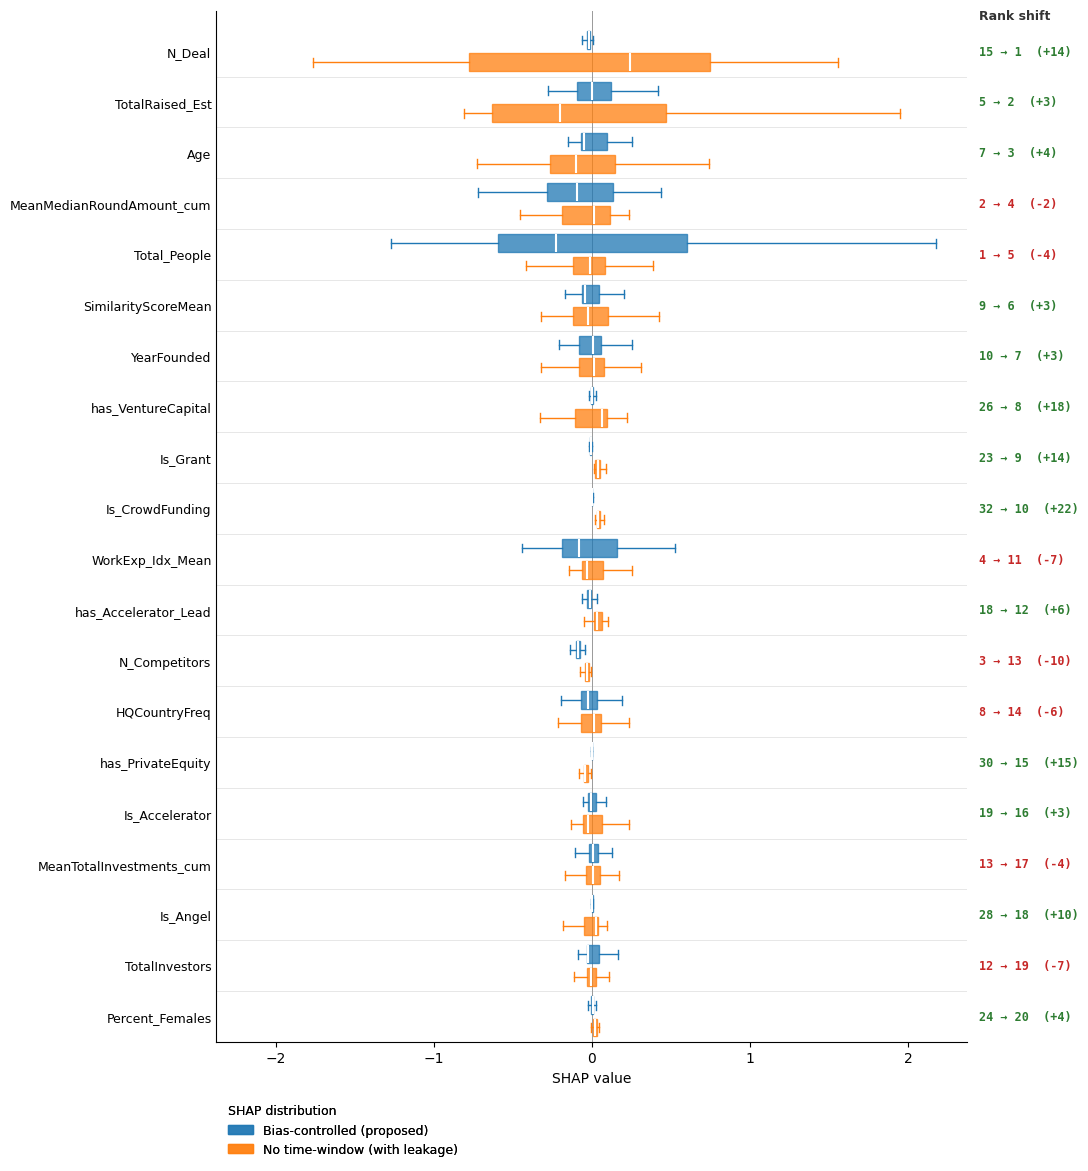

In [20]:
fig = plot_shap_comparison(shap_store)
plt.show()

In [42]:
df_wilcoxon = compute_wilcoxon_table(shap_store)
print(df_wilcoxon.to_string(index=False))

                  Feature  Mean |SHAP| w.  Mean |SHAP| w/o w.     Diff.  wilcoxon_p_value Signif.
                   N_Deal        0.039386            0.737777 -0.698391     3.924813e-163      **
          TotalRaised_Est        0.119701            0.607502 -0.487801     6.928126e-153      **
                      Age        0.085805            0.233624 -0.147819     1.470772e-122      **
MeanMedianRoundAmount_cum        0.219108            0.139323  0.079785      6.655113e-47      **
             Total_People        0.682584            0.132969  0.549615     4.944976e-158      **
      SimilarityScoreMean        0.072256            0.130531 -0.058276      4.676824e-49      **
              YearFounded        0.071583            0.113883 -0.042300      1.325412e-13      **
       has_VentureCapital        0.007783            0.109334 -0.101551     3.325859e-165      **
                 Is_Grant        0.016311            0.079762 -0.063451     7.267125e-127      **
          Is_CrowdFu

### Comparison across window and noteam experiments
You need to run both the "window" and "noteam" runs before executing the following code, to ensure that shap_store and metrics_store contains the necessary data for both configurations

In [34]:
df_cmp_noteam = compare_metrics(metrics_store, "window", "noteam")
print(df_cmp_noteam.to_string(index=False))

         Model          AUC           F1    precision       recall    accuracy accuracy_train
            lr         0.79         0.61         0.58         0.65        0.74           0.73
 lr w/o window 0.71(-10.1%) 0.54(-11.5%) 0.50(-13.8%)  0.60(-7.7%) 0.68(-8.1%)    0.67(-8.2%)
            dt         0.79         0.62         0.52         0.77        0.70           0.70
 dt w/o window  0.72(-8.9%) 0.54(-12.9%)  0.50(-3.8%) 0.60(-22.1%) 0.68(-2.9%)    0.69(-1.4%)
            rf         0.81         0.63         0.59         0.67        0.75           0.81
 rf w/o window  0.74(-8.6%) 0.56(-11.1%)  0.54(-8.5%) 0.59(-11.9%) 0.71(-5.3%)    0.77(-4.9%)
           lgb         0.81         0.64         0.57         0.71        0.74           0.76
lgb w/o window  0.75(-7.4%) 0.57(-10.9%)  0.53(-7.0%) 0.63(-11.3%) 0.70(-5.4%)    0.72(-5.3%)
           mlp         0.80         0.63         0.57         0.70        0.73           0.75
mlp w/o window  0.73(-8.8%) 0.56(-11.1%)  0.52(-8.8%) 0.60(-

### Comparison across window and nocompetitors experiments
You need to run both the "window" and "nocompetitors" runs before executing the following code, to ensure that shap_store and metrics_store contains the necessary data for both configurations

In [41]:
df_cmp_nocompetitors = compare_metrics(metrics_store, "window", "nocompetitors")
print(df_cmp_nocompetitors.to_string(index=False))

         Model         AUC          F1   precision       recall    accuracy accuracy_train
            lr        0.79        0.61        0.58         0.65        0.74           0.73
 lr w/o window 0.78(-1.3%) 0.61(+0.0%) 0.57(-1.7%)  0.65(+0.0%) 0.73(-1.4%)    0.72(-1.4%)
            dt        0.79        0.62        0.52         0.77        0.70           0.70
 dt w/o window 0.77(-2.5%) 0.61(-1.6%) 0.56(+7.7%) 0.68(-11.7%) 0.72(+2.9%)    0.72(+2.9%)
            rf        0.81        0.63        0.59         0.67        0.75           0.81
 rf w/o window 0.79(-2.5%) 0.61(-3.2%) 0.58(-1.7%)  0.65(-3.0%) 0.74(-1.3%)    0.81(+0.0%)
           lgb        0.81        0.64        0.57         0.71        0.74           0.76
lgb w/o window 0.80(-1.2%) 0.63(-1.6%) 0.56(-1.8%)  0.71(+0.0%) 0.73(-1.4%)    0.75(-1.3%)
           mlp        0.80        0.63        0.57         0.70        0.73           0.75
mlp w/o window 0.79(-1.3%) 0.62(-1.6%) 0.55(-3.5%)  0.71(+1.4%) 0.72(-1.4%)    0.73(-2.7%)